C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\Admin\.cache\kagglehub\datasets\sharmajicoder\used-phone-price-prediction-dataset\versions\1
Successfully loaded used_phone_price_prediction_1M.csv! Data shape: (1000000, 28)


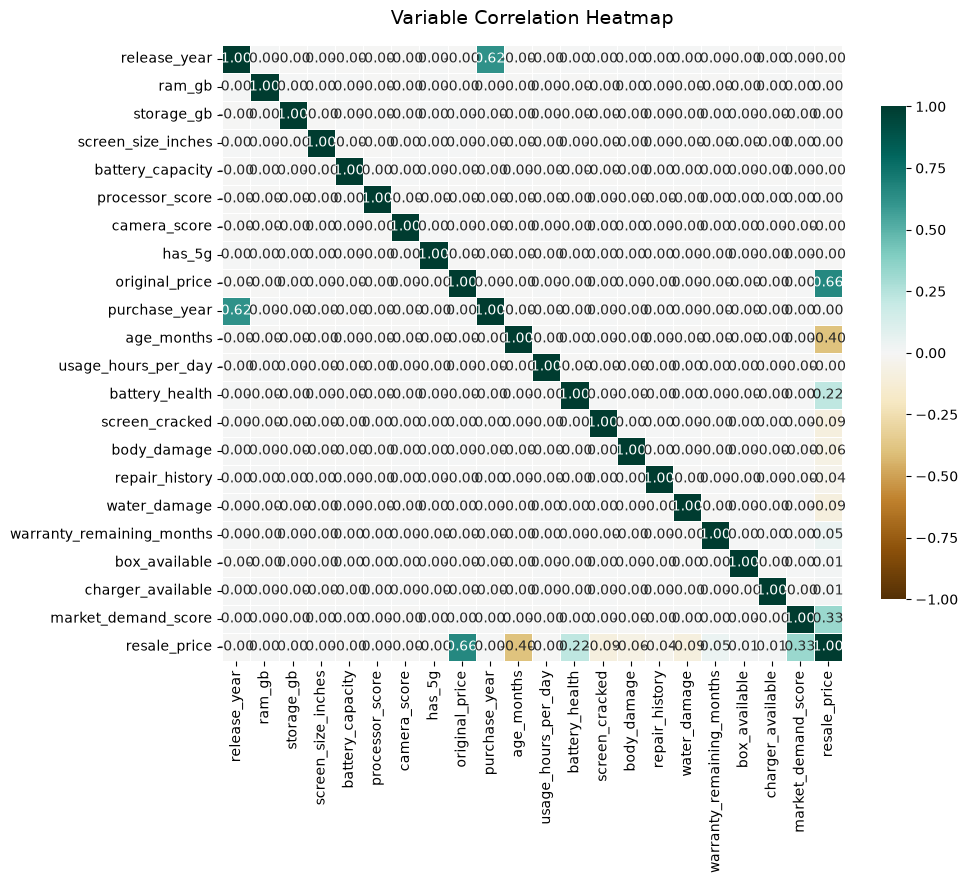

In [2]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download the latest version of the dataset
path = kagglehub.dataset_download("sharmajicoder/used-phone-price-prediction-dataset")
print("Dataset downloaded to:", path)

# 2. Automatically find the CSV file inside the downloaded folder
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset folder!")

# Grab the first CSV file found
csv_file_name = csv_files[0]
full_path = os.path.join(path, csv_file_name)

# 3. Load the dataset cleanly into a Pandas DataFrame
df = pd.read_csv(full_path)
print(f"Successfully loaded {csv_file_name}! Data shape: {df.shape}")

# 4. Generate an ultimate, highly-readable correlation heatmap
plt.figure(figsize=(10, 8))  # Gives the plot plenty of breathing room

# Filter out non-numeric columns automatically to prevent correlation errors
numeric_df = df.select_dtypes(include=['number'])

if not numeric_df.empty:
    sns.heatmap(
        numeric_df.corr(), 
        annot=True,             # Shows the correlation numbers inside the boxes
        fmt=".2f",              # Limits the numbers to 2 decimal places for cleanliness
        cmap="BrBG",            # Sophisticated Brown-to-Teal palette (clean & professional)
        vmin=-1,                # Anchor the minimum scale to -1
        vmax=1,                 # Anchor the maximum scale to 1
        linewidths=0.5,         # Adds subtle lines between grid cells
        cbar_kws={"shrink": 0.8} # Makes the side color-bar look well-proportioned
    )
    plt.title("Variable Correlation Heatmap", fontsize=14, pad=15)
    plt.show()
else:
    print("No numeric columns found to correlate!")

In [3]:
df.head()

,brand,model,release_year,ram_gb,storage_gb,screen_size_inches,battery_capacity,processor_score,camera_score,os_type,...,body_damage,repair_history,water_damage,city_tier,seller_type,warranty_remaining_months,box_available,charger_available,market_demand_score,resale_price
0,Realme,Realme GT,2025,4,256,6.93,4130,47,100,Android,...,0,0,0,Tier1,Individual,11,1,1,99,47891.46
1,Samsung,Galaxy S21,2024,16,64,6.29,5558,81,67,Android,...,0,0,0,Tier3,Store,8,1,0,64,17663.21
2,Apple,iPhone 11,2022,4,128,5.52,5945,59,67,iOS,...,0,0,0,Tier1,Individual,0,0,1,68,67268.20
3,Google,Pixel 6,2024,16,512,5.99,5767,84,57,Android,...,0,0,1,Tier1,Store,11,1,1,50,12626.26
4,Google,Pixel 7,2021,4,128,6.59,5336,98,44,Android,...,0,0,0,Tier3,Store,24,1,1,66,20662.25


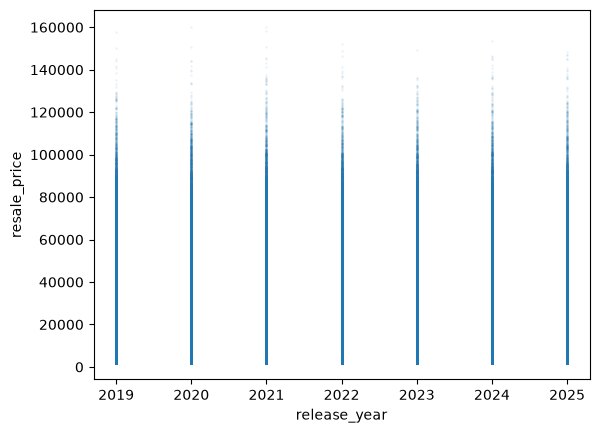

In [4]:
plt.scatter(
    df["release_year"],
    df["resale_price"],
    s = 1,
    alpha=0.05
)

plt.xlabel("release_year")
plt.ylabel("resale_price")

plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 's'

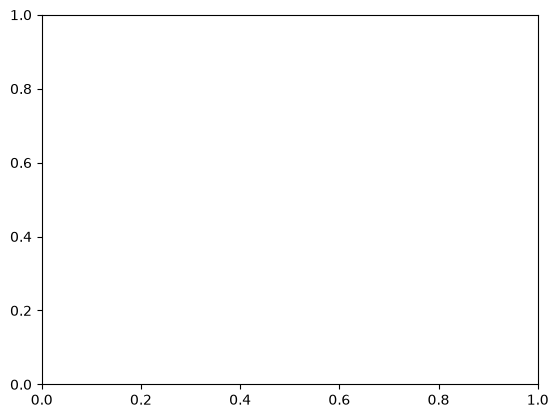

In [5]:
plt.bar(
    df["release_year"],
    df["resale_price"],
    s = 5
)

plt.xlabel("release_year")
plt.ylabel("resale_price")

plt.show()